New Figures for *Neurocomputing* Paper. This file mainly provides code for Figure generation, with some explanation in the objectives and theory. Most of the theory is given in `basics.ipynb`.

# Imports

In [2]:
# Imports
import os
import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym
import multiprocess as mp
import pickle
import torch
from time import perf_counter
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

from coin import COIN
from environments import CustomMountainCarEnv
from rl import QLearningAgent, COINQLearningAgent

%matplotlib inline
%load_ext autoreload
%autoreload 2

# Figure 7: Training Performance

Displays the performance of the model as it is trained. We choose here to use a simple Mountain Car with Q-Learning, since it is our simplest algorithm, with stability guarantees. We vary the *gravitational strength* of the path as a parameter, and then do direct sequential training with a few different models:
1. *Default, Zero-shot Single Policy*: Traditional Q-learning. No knowledge of contextual parameter.
2. *N-policy oracle setup*: Contextual Q-learning, where learning is divided between $N$ different policies, each activating for a different regime of simulation parameter (*oracle* comes from the fact that this parameter and the underlying regime assignment is known by the agent).
3. *COIN approach*: Our initial model. Assumes COIN directly infers context probabilities through measurements of the contextual parameter (in this case given), and then builds new policies at real-time through training whenever new contexts are instantiated.
4. *Embodied COIN approach*: COIN is implemented with a slow learning body that is **pre-trained**, i.e. a body that is already adapted to the environment. This is our main targetted approach. We also show a line for a *headless* behaviour, what happens if the contexts are cut-off and the model only uses the body information.

In [3]:
param = np.concatenate([
    0.0*np.ones((500, )), 
    1.0*np.ones((500, )),
    1.5*np.ones((500, )),
    0.5*np.ones((500, )),
    0.5*np.ones((500, )),
    1.5*np.ones((500, )),
    0.0*np.ones((500, )),
    1.0*np.ones((500, )),
    1.0*np.ones((500, ))
    ])

N_REPS = 10 # Number of repetitions of each model for averaging
MAX_CORES = mp.cpu_count() - 1 # Number of parallel processes to use
TRAIN = True # Set to True to train, False to load saved results

## Parameter Variation

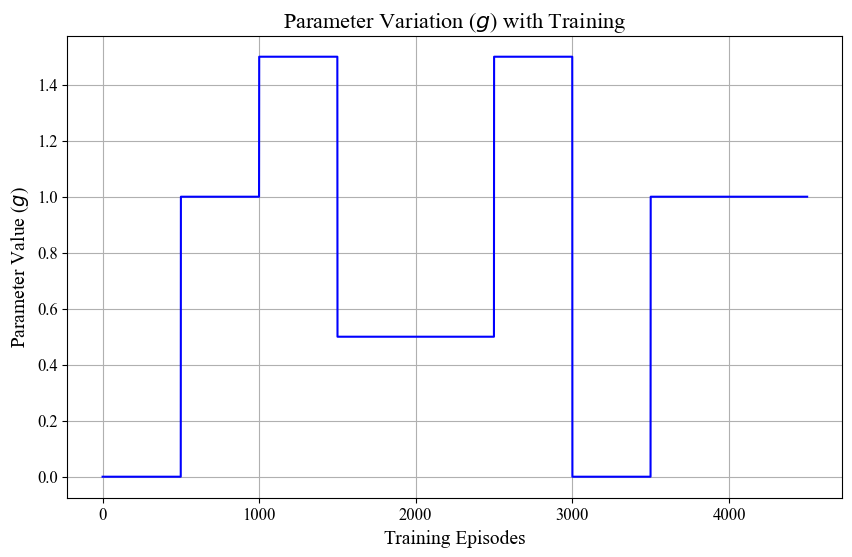

In [4]:
# Plot parameter variation
# Font setup
plt.rcParams.update({
    "font.family": "Times New Roman",
    "font.size": 14,
    "axes.titlesize": 16,
    "axes.labelsize": 14,
    "legend.fontsize": 13,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12
})

# Create figure and axiss
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(param, color='blue')
ax.set_title(r'Parameter Variation ($g$) with Training')
ax.set_xlabel('Training Episodes')
ax.set_ylabel(r'Parameter Value ($g$)')
ax.grid(True)
plt.show()


## Zero-shot one policy model

In [5]:
def run_single_zero_shot_F7(rep_id, g):
    """
    Runs one repetition of training with a simple Q-learning agent on the CustomMountainCarEnv, with gravitational variation
    per episode as defined by g.
    Returns the list of rewards obtained for each episode.
    """
    # Imports for multiprocessing
    from environments import CustomMountainCarEnv
    from rl import QLearningAgent

    # Create a fresh agent and environment inside each process
    env = CustomMountainCarEnv(gravity=g[0], render_mode="none")
    agent = QLearningAgent(
        env=env,
        num_position_bins=30,
        num_velocity_bins=30,
        alpha=0.1,
        gamma=0.99,
        epsilon=1.0,
        epsilon_decay=0.999,
        min_epsilon=0.01
    )

    rewards_for_this_rep = []
    for i, gravity in enumerate(g):
        # Create the environment for each gravity
        env = CustomMountainCarEnv(gravity=gravity, render_mode="none")
        
        # Train the agent in the current context
        training_reward = agent.train_step(env=env, max_steps_per_episode=200)
        rewards_for_this_rep.append(training_reward)

        # Reset the environment epsilon at a change in gravity
        if i > 0 and gravity != g[i - 1]:
            agent.epsilon = 1.0

        if (i + 1) % 500 == 0:
            print(f"Repetition {rep_id}, Gravity {gravity}: Training reward = {training_reward}")
    return rewards_for_this_rep

REWARDS_PATH = "models/fig7_zeroshot.npy"
if TRAIN:
    # Number of repetitions and number of parallel processes:
    n_reps = N_REPS
    n_processes = MAX_CORES
        
    # Create a Pool of workers
    with mp.Pool(processes=n_processes) as pool:
        # Map each repetition to the function run_single_zero_shot_F7
        all_results = pool.starmap(run_single_zero_shot_F7, [(rep, param) for rep in range(n_reps)])
        
    # all_results is a list of lists: one list of rewards for each repetition
    # Convert to a NumPy array, then average over axis=0 to get mean reward per amplitude
    all_results_array = np.array(all_results)  # shape: (n_reps, len(sf))
    rewards_F7_zeroshot = np.mean(all_results_array, axis=0)

    # Also get error bars (std dev) for plotting
    rewards_F7_zeroshot_std = np.std(all_results_array, axis=0)

    # Concatenate into a single array for saving
    rewards_F7_zeroshot = np.vstack((rewards_F7_zeroshot, rewards_F7_zeroshot_std))

    # Save results
    np.save(REWARDS_PATH, rewards_F7_zeroshot)
    print(f"Training complete. Rewards saved to '{REWARDS_PATH}'.")
else:
    # Load the saved results from the training
    if os.path.exists(REWARDS_PATH):
        rewards_basic = np.load(REWARDS_PATH)
        print(f"Loaded rewards from '{REWARDS_PATH}'.")
    else:
        raise FileNotFoundError(f"No saved rewards found at '{REWARDS_PATH}'.")

Training complete. Rewards saved to 'models/fig7_zeroshot.npy'.


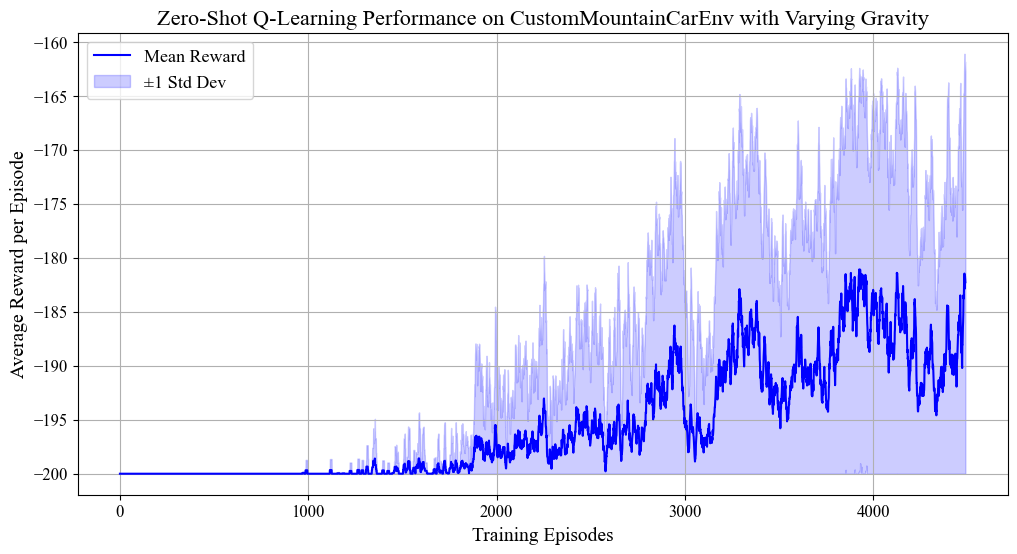

In [8]:
# Plot training results and confidence region
# Create figure and axis
fig, ax = plt.subplots(figsize=(12, 6))
# Extract mean rewards and std dev - smooth for plotting
mean_rewards = np.convolve(rewards_F7_zeroshot[0], np.ones(10)/10, mode='valid')
std_rewards = np.convolve(rewards_F7_zeroshot[1], np.ones(10)/10, mode='valid')
# Plot mean rewards
ax.plot(mean_rewards, label='Mean Reward', color='blue')
# Plot confidence region
ax.fill_between(
    range(len(mean_rewards)),
    np.clip(mean_rewards - std_rewards, a_min=-200, a_max=None),
    mean_rewards + std_rewards,
    color='blue',
    alpha=0.2,
    label='±1 Std Dev'
) 
ax.set_title('Zero-Shot Q-Learning Performance on CustomMountainCarEnv with Varying Gravity')
ax.set_xlabel('Training Episodes')
ax.set_ylabel('Average Reward per Episode')
ax.legend()
ax.grid(True)
plt.show()


## Oracle N-Policy Model

In [ ]:
# Set up p_context
p_contexts = np.zeros((len(param), 5))
p_contexts[param == 0.0, 0] = 1.0
p_contexts[param == 0.5, 1] = 1.0
p_contexts[param == 1.0, 2] = 1.0
p_contexts[param == 1.5, 3] = 1.0

def run_single_rep_oracle_F7(rep_id, g, p_context):
    """
    Runs one repetition of training across all gravitational values in g using COINQLearningAgent with oracle context (gravity).
    Returns the list of rewards.
    """
    # Imports for multiprocessing
    from environments import CustomMountainCarEnv
    from rl import COINQLearningAgent
    # Create a fresh agent and environment inside each process

    C = p_context.shape[1]-1

    env = CustomMountainCarEnv(amplitude=1.0, render_mode="none")
    agent = COINQLearningAgent(
        env=env,
        max_contexts=C,
        num_position_bins=30,
        num_velocity_bins=30,
        alpha=0.1,
        gamma=0.99,
        epsilon=1.0,
        epsilon_decay=0.999
    )

    rewards_for_this_rep = []
    for i, val in enumerate(g):
        # Create the environment for each amplitude
        env = CustomMountainCarEnv(gravity=val, render_mode="none")
        
        # Train the agent in the current context
        training_reward = agent.train_step(env=env, p_context=p_context[i,:], max_steps_per_episode=200)
        rewards_for_this_rep.append(training_reward)

        if (i + 1) % 500 == 0:
            print(f"Repetition {rep_id}, Gravity {val}: Training reward = {training_reward}")

    return rewards_for_this_rep

REWARDS_PATH = "models/fig7_rewards_oracle.npy"
if TRAIN:
    # Number of repetitions and number of parallel processes:
    n_reps = N_REPS
    n_processes = MAX_CORES
        
    # Create a Pool of workers
    with mp.Pool(processes=n_processes) as pool:
        # Map each repetition to the function run_single_rep_oracle_F7
        all_results = pool.starmap(run_single_rep_oracle_F7, [(rep, param, p_contexts) for rep in range(n_reps)])
        
    # all_results is a list of lists: one list of rewards for each repetition
    # Convert to a NumPy array, then average over axis=0 to get mean reward per amplitude
    all_results_array = np.array(all_results)  # shape: (n_reps, len(sf))
    rewards_F7_oracle = np.mean(all_results_array, axis=0)
    # Also get error bars (std dev) for plotting
    rewards_F7_oracle_std = np.std(all_results_array, axis=0)

    # Concatenate into a single array for saving
    rewards_F7_oracle = np.vstack((rewards_F7_oracle, rewards_F7_oracle_std))

    # Save results
    np.save(REWARDS_PATH, rewards_F7_oracle)
    print(f"Training complete. Rewards saved to '{REWARDS_PATH}'.")
else:
    # Load the saved results from the training
    if os.path.exists(REWARDS_PATH):
        rewards_F7_oracle = np.load(REWARDS_PATH)
        print(f"Loaded rewards from '{REWARDS_PATH}'.")
    else:
        raise FileNotFoundError(f"No saved rewards found at '{REWARDS_PATH}'.")

Training complete. Rewards saved to 'models/fig7_rewards_oracle.npy'.


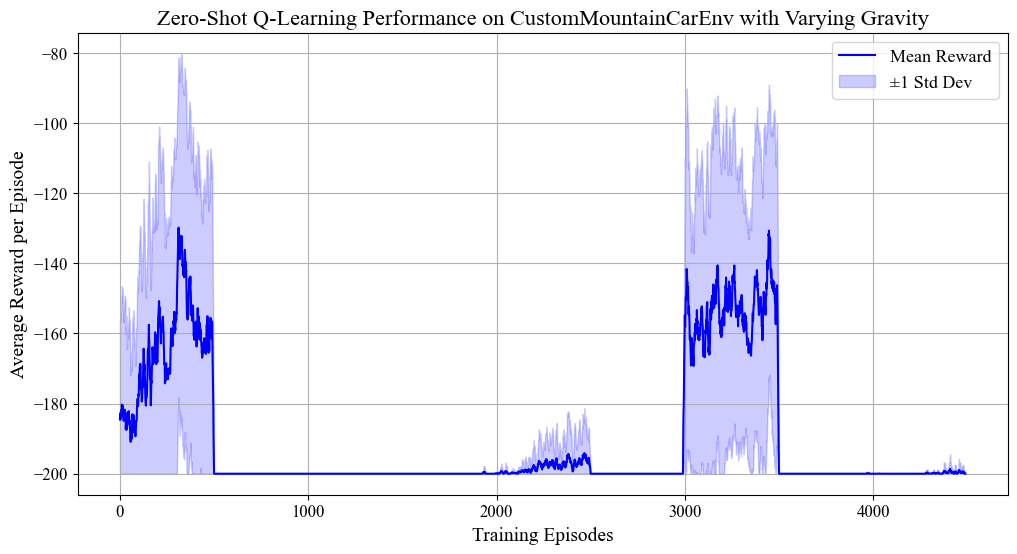

In [ ]:
# Plot training results and confidence region
# Create figure and axis
fig, ax = plt.subplots(figsize=(12, 6))
# Extract mean rewards and std dev - smooth for plotting
mean_rewards = np.convolve(rewards_F7_oracle[0], np.ones(10)/10, mode='valid')
std_rewards = np.convolve(rewards_F7_oracle[1], np.ones(10)/10, mode='valid')
# Plot mean rewards
ax.plot(mean_rewards, label='Mean Reward', color='blue')
# Plot confidence region
ax.fill_between(
    range(len(mean_rewards)),
    np.clip(mean_rewards - std_rewards, a_min=-200, a_max=None),
    mean_rewards + std_rewards,
    color='blue',
    alpha=0.2,
    label='±1 Std Dev'
) 
ax.set_title('Oracle Performance on CustomMountainCarEnv with Varying Gravity')
ax.set_xlabel('Training Episodes')
ax.set_ylabel('Average Reward per Episode')
ax.legend()
ax.grid(True)
plt.show()

## COIN approach

In [14]:
# Set up p_context - from COIN
coin_model = COIN(
    sigma_sensory_noise = 0.003, 
    sigma_motor_noise = 0.00182,
)

# Simplify COIN calculation by assuming parameters stay the same every 50 episodes
coin_model.perturbations = param[::50]

output = coin_model.simulate_coin()

known_c_resp, novel_c_resp = coin_model.get_responsibilities(output)
p_contexts = np.concatenate([known_c_resp,novel_c_resp[:,None]],axis=-1) 
p_contexts = np.repeat(p_contexts, repeats=50, axis=0)

# Ensure COIN probabilities are of the right form
# Novel context - should never have a NaN definition
p_temp = p_contexts.copy()
p_temp[np.isnan(p_temp)] = 0.0
p_contexts[:,-1] = 1 - np.sum(p_temp[:,:-1], axis=1)

def run_single_rep_coin_F7(rep_id, g, p_context):
    """
    Runs one repetition of training across all gravitational values in g using COINQLearningAgent with COIN p_contexts.
    Returns the list of rewards.
    """
    # Imports for multiprocessing
    from environments import CustomMountainCarEnv
    from rl import COINQLearningAgent
    # Create a fresh agent and environment inside each process

    C = p_context.shape[1]-1

    env = CustomMountainCarEnv(amplitude=1.0, render_mode="none")
    agent = COINQLearningAgent(
        env=env,
        max_contexts=C,
        num_position_bins=30,
        num_velocity_bins=30,
        alpha=0.1,
        gamma=0.99,
        epsilon=1.0,
        epsilon_decay=0.999
    )

    rewards_for_this_rep = []
    for i, val in enumerate(g):
        # Create the environment for each amplitude
        env = CustomMountainCarEnv(gravity=val, render_mode="none")
        
        # Train the agent in the current context
        training_reward = agent.train_step(env=env, p_context=p_context[i,:], max_steps_per_episode=200)
        rewards_for_this_rep.append(training_reward)

        if (i + 1) % 500 == 0:
            print(f"Repetition {rep_id}, Gravity {val}: Training reward = {training_reward}")

    return rewards_for_this_rep

REWARDS_PATH = "models/fig7_rewards_coin.npy"
if TRAIN:
    # Number of repetitions and number of parallel processes:
    n_reps = N_REPS
    n_processes = MAX_CORES
        
    # Create a Pool of workers
    with mp.Pool(processes=n_processes) as pool:
        # Map each repetition to the function run_single_rep_coin_F7
        all_results = pool.starmap(run_single_rep_coin_F7, [(rep, param, p_contexts) for rep in range(n_reps)])
        
    # all_results is a list of lists: one list of rewards for each repetition
    # Convert to a NumPy array, then average over axis=0 to get mean reward per amplitude
    all_results_array = np.array(all_results)  # shape: (n_reps, len(sf))
    rewards_F7_coin = np.mean(all_results_array, axis=0)
    # Also get error bars (std dev) for plotting
    rewards_F7_coin_std = np.std(all_results_array, axis=0)

    # Concatenate into a single array for saving
    rewards_F7_coin = np.vstack((rewards_F7_coin, rewards_F7_coin_std))

    # Save results
    np.save(REWARDS_PATH, rewards_F7_coin)
    print(f"Training complete. Rewards saved to '{REWARDS_PATH}'.")
else:
    # Load the saved results from the training
    if os.path.exists(REWARDS_PATH):
        rewards_F7_coin = np.load(REWARDS_PATH)
        print(f"Loaded rewards from '{REWARDS_PATH}'.")
    else:
        raise FileNotFoundError(f"No saved rewards found at '{REWARDS_PATH}'.")

Simulating the COIN model
Finding optimal context labels (trial = 50)
Permuting context labels (trial = 50)
Training complete. Rewards saved to 'models/fig7_rewards_coin.npy'.


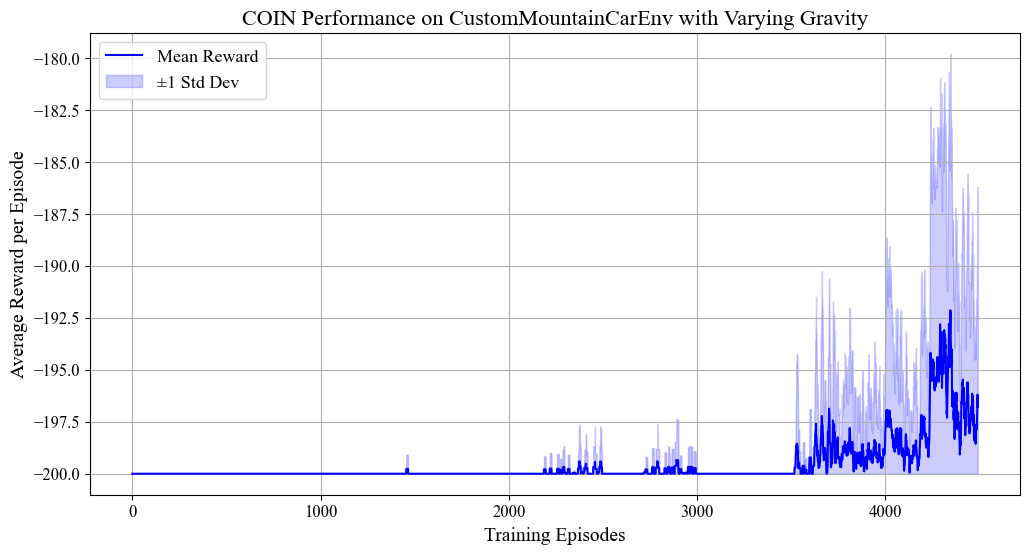

In [15]:
# Plot training results and confidence region
# Create figure and axis
fig, ax = plt.subplots(figsize=(12, 6))
# Extract mean rewards and std dev - smooth for plotting
mean_rewards = np.convolve(rewards_F7_coin[0], np.ones(10)/10, mode='valid')
std_rewards = np.convolve(rewards_F7_coin[1], np.ones(10)/10, mode='valid')
# Plot mean rewards
ax.plot(mean_rewards, label='Mean Reward', color='blue')
# Plot confidence region
ax.fill_between(
    range(len(mean_rewards)),
    np.clip(mean_rewards - std_rewards, a_min=-200, a_max=None),
    mean_rewards + std_rewards,
    color='blue',
    alpha=0.2,
    label='±1 Std Dev'
) 
ax.set_title('COIN Performance on CustomMountainCarEnv with Varying Gravity')
ax.set_xlabel('Training Episodes')
ax.set_ylabel('Average Reward per Episode')
ax.legend()
ax.grid(True)
plt.show()

## Embodied COIN Approach

In [17]:
# Train basic Q-learning agent on g=1.0 as our body

# Create the Q-learning agent
env = CustomMountainCarEnv(gravity=1.0, render_mode="none")
body_agent = QLearningAgent(
    env=env,
    num_position_bins=30,
    num_velocity_bins=30,
    alpha=0.1,
    gamma=0.99,
    epsilon=1.0,
    epsilon_decay=0.999,
    min_epsilon=0.01
)

rewards_for_this_rep = []
for i in range(10000):    
    # Train the agent in the current context
    training_reward = body_agent.train_step(env=env, max_steps_per_episode=200)
    rewards_for_this_rep.append(training_reward)

    if (i + 1) % 500 == 0:
        print(f"Episode {i}: Training reward = {training_reward}")


Episode 499: Training reward = -200.0
Episode 999: Training reward = -200.0
Episode 1499: Training reward = -200.0
Episode 1999: Training reward = -200.0
Episode 2499: Training reward = -200.0
Episode 2999: Training reward = -200.0
Episode 3499: Training reward = -200.0
Episode 3999: Training reward = -196.0
Episode 4499: Training reward = -200.0
Episode 4999: Training reward = -171.0
Episode 5499: Training reward = -163.0
Episode 5999: Training reward = -184.0
Episode 6499: Training reward = -156.0
Episode 6999: Training reward = -181.0
Episode 7499: Training reward = -152.0
Episode 7999: Training reward = -200.0
Episode 8499: Training reward = -152.0
Episode 8999: Training reward = -162.0
Episode 9499: Training reward = -164.0
Episode 9999: Training reward = -200.0


In [19]:
# Set up p_context - from COIN
coin_model = COIN(
    sigma_sensory_noise = 0.003, 
    sigma_motor_noise = 0.00182,
)

# Simplify COIN calculation by assuming parameters stay the same every 50 episodes
coin_model.perturbations = param[::50]

output = coin_model.simulate_coin()

known_c_resp, novel_c_resp = coin_model.get_responsibilities(output)
p_contexts = np.concatenate([known_c_resp,novel_c_resp[:,None]],axis=-1) 
p_contexts = np.repeat(p_contexts, repeats=50, axis=0)

# Ensure COIN probabilities are of the right form
# Novel context - should never have a NaN definition
p_temp = p_contexts.copy()
p_temp[np.isnan(p_temp)] = 0.0
p_contexts[:,-1] = 1 - np.sum(p_temp[:,:-1], axis=1)

def run_single_rep_coin_F7(rep_id, g, p_context, body_Q):
    """
    Runs one repetition of training across all gravitational values in g using COINQLearningAgent with COIN p_contexts.
    Returns the list of rewards.
    """
    # Imports for multiprocessing
    from environments import CustomMountainCarEnv
    from rl import EmbodiedCOINQLearningAgent
    # Create a fresh agent and environment inside each process

    C = p_context.shape[1]-1

    env = CustomMountainCarEnv(amplitude=1.0, render_mode="none")
    agent = EmbodiedCOINQLearningAgent(
        env=env,
        max_contexts=C,
        num_position_bins=30,
        num_velocity_bins=30,
        alpha=0.1,
        alpha_body=1e-5,
        gamma=0.99,
        epsilon=1.0,
        epsilon_decay=0.999
    )

    # Set body Q-learning table
    agent.Qbody = body_Q.copy()

    rewards_for_this_rep = []
    for i, val in enumerate(g):
        # Create the environment for each amplitude
        env = CustomMountainCarEnv(gravity=val, render_mode="none")
        
        # Train the agent in the current context
        training_reward = agent.train_step(env=env, p_context=p_context[i,:], max_steps_per_episode=200)
        rewards_for_this_rep.append(training_reward)

        if (i + 1) % 500 == 0:
            print(f"Repetition {rep_id}, Gravity {val}: Training reward = {training_reward}")

    return rewards_for_this_rep

REWARDS_PATH = "models/fig7_rewards_embodied_coin.npy"
if TRAIN:
    # Number of repetitions and number of parallel processes:
    n_reps = N_REPS
    n_processes = MAX_CORES
        
    # Create a Pool of workers
    with mp.Pool(processes=n_processes) as pool:
        # Map each repetition to the function run_single_rep_coin_F7
        all_results = pool.starmap(run_single_rep_coin_F7, [(rep, param, p_contexts, body_agent.Q.copy()) for rep in range(n_reps)])
        
    # all_results is a list of lists: one list of rewards for each repetition
    # Convert to a NumPy array, then average over axis=0 to get mean reward per amplitude
    all_results_array = np.array(all_results)  # shape: (n_reps, len(sf))
    rewards_F7_embodied_coin = np.mean(all_results_array, axis=0)
    # Also get error bars (std dev) for plotting
    rewards_F7_embodied_coin_std = np.std(all_results_array, axis=0)

    # Concatenate into a single array for saving
    rewards_F7_embodied_coin = np.vstack((rewards_F7_embodied_coin, rewards_F7_embodied_coin_std))

    # Save results
    np.save(REWARDS_PATH, rewards_F7_embodied_coin)
    print(f"Training complete. Rewards saved to '{REWARDS_PATH}'.")
else:
    # Load the saved results from the training
    if os.path.exists(REWARDS_PATH):
        rewards_F7_embodied_coin = np.load(REWARDS_PATH)
        print(f"Loaded rewards from '{REWARDS_PATH}'.")
    else:
        raise FileNotFoundError(f"No saved rewards found at '{REWARDS_PATH}'.")

Simulating the COIN model
Finding optimal context labels (trial = 50)
Permuting context labels (trial = 50)
Training complete. Rewards saved to 'models/fig7_rewards_embodied_coin.npy'.


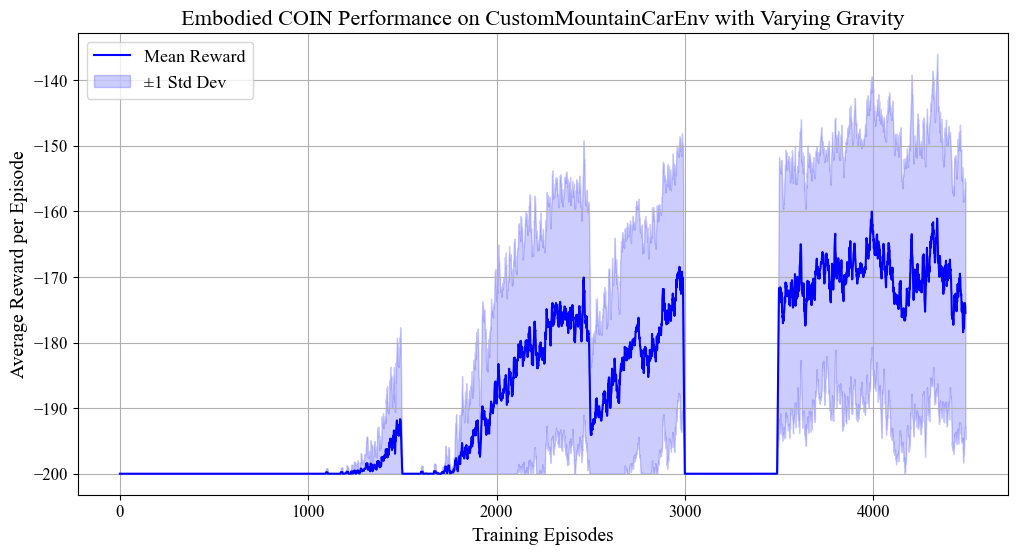

In [22]:
# Plot training results and confidence region
# Create figure and axis
fig, ax = plt.subplots(figsize=(12, 6))
# Extract mean rewards and std dev - smooth for plotting
mean_rewards = np.convolve(rewards_F7_embodied_coin[0], np.ones(10)/10, mode='valid')
std_rewards = np.convolve(rewards_F7_embodied_coin[1], np.ones(10)/10, mode='valid')
# Plot mean rewards
ax.plot(mean_rewards, label='Mean Reward', color='blue')
# Plot confidence region
ax.fill_between(
    range(len(mean_rewards)),
    np.clip(mean_rewards - std_rewards, a_min=-200, a_max=None),
    mean_rewards + std_rewards,
    color='blue',
    alpha=0.2,
    label='±1 Std Dev'
) 
ax.set_title('Embodied COIN Performance on CustomMountainCarEnv with Varying Gravity')
ax.set_xlabel('Training Episodes')
ax.set_ylabel('Average Reward per Episode')
ax.legend()
ax.grid(True)
plt.show()

In [30]:
# Also evaluate the body agent (without training) for the parameter values
def run_single_rep_body(rep_id, g, body_Q):
    """
    Runs one repetition of training across all gravitational values in g using COINQLearningAgent with COIN p_contexts.
    Returns the list of rewards.
    """
    # Imports for multiprocessing
    from environments import CustomMountainCarEnv
    from rl import QLearningAgent
    # Create a fresh agent and environment inside each process

    env = CustomMountainCarEnv(gravity=1.0, render_mode="none")
    agent = QLearningAgent(
        env=env,
        num_position_bins=30,
        num_velocity_bins=30,
        alpha=0.1,
        gamma=0.99,
        epsilon=1.0,
        epsilon_decay=0.999,
        min_epsilon=0.01
    )

    # Set body Q-learning table
    agent.Qbody = body_Q.copy()

    rewards_for_this_rep = []
    for i, val in enumerate(g):
        # Create the environment for each amplitude
        env = CustomMountainCarEnv(gravity=val, render_mode="none")
        
        # Train the agent in the current context
        training_reward = agent.evaluate(env=env, n_episodes=1, max_steps_per_episode=200)
        rewards_for_this_rep.append(training_reward[0])

        if (i + 1) % 500 == 0:
            print(f"Repetition {rep_id}, Gravity {val}: Training reward = {training_reward}")

    return rewards_for_this_rep

REWARDS_PATH = "models/fig7_rewards_body.npy"
if TRAIN:
    # Number of repetitions and number of parallel processes:
    n_reps = N_REPS
    n_processes = MAX_CORES
        
    # Create a Pool of workers
    with mp.Pool(processes=n_processes) as pool:
        # Map each repetition to the function run_single_rep_body
        all_results = pool.starmap(run_single_rep_body, [(rep, param, body_agent.Q.copy()) for rep in range(n_reps)])
        
    # all_results is a list of lists: one list of rewards for each repetition
    # Convert to a NumPy array, then average over axis=0 to get mean reward per amplitude
    all_results_array = np.array(all_results)  # shape: (n_reps, len(sf))
    rewards_F7_body = np.mean(all_results_array, axis=0)
    # Also get error bars (std dev) for plotting
    rewards_F7_body_std = np.std(all_results_array, axis=0)

    # Concatenate into a single array for saving
    rewards_F7_body = np.vstack((rewards_F7_body, rewards_F7_body_std))

    # Save results
    np.save(REWARDS_PATH, rewards_F7_body)
    print(f"Training complete. Rewards saved to '{REWARDS_PATH}'.")
else:
    # Load the saved results from the training
    if os.path.exists(REWARDS_PATH):
        rewards_F7_body = np.load(REWARDS_PATH)
        print(f"Loaded rewards from '{REWARDS_PATH}'.")
    else:
        raise FileNotFoundError(f"No saved rewards found at '{REWARDS_PATH}'.")

Training complete. Rewards saved to 'models/fig7_rewards_body.npy'.


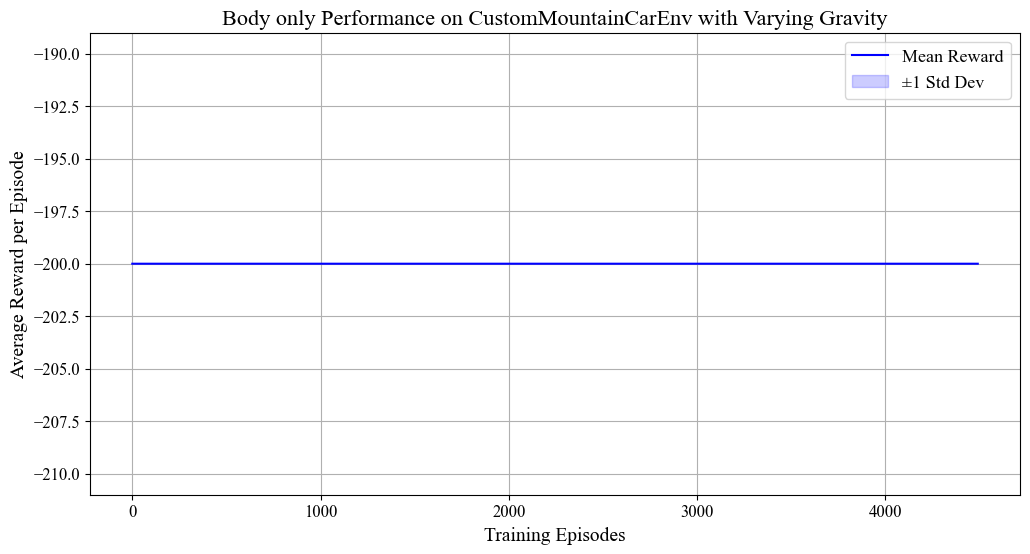

In [31]:
# Plot evaluation results and confidence region
# Create figure and axis
fig, ax = plt.subplots(figsize=(12, 6))
# Extract mean rewards and std dev - smooth for plotting
mean_rewards = np.convolve(rewards_F7_body[0], np.ones(10)/10, mode='valid')
std_rewards = np.convolve(rewards_F7_body[1], np.ones(10)/10, mode='valid')
# Plot mean rewards
ax.plot(mean_rewards, label='Mean Reward', color='blue')
# Plot confidence region
ax.fill_between(
    range(len(mean_rewards)),
    np.clip(mean_rewards - std_rewards, a_min=-200, a_max=None),
    mean_rewards + std_rewards,
    color='blue',
    alpha=0.2,
    label='±1 Std Dev'
) 
ax.set_title('Body only Performance on CustomMountainCarEnv with Varying Gravity')
ax.set_xlabel('Training Episodes')
ax.set_ylabel('Average Reward per Episode')
ax.legend()
ax.grid(True)
plt.show()

## Final Plot

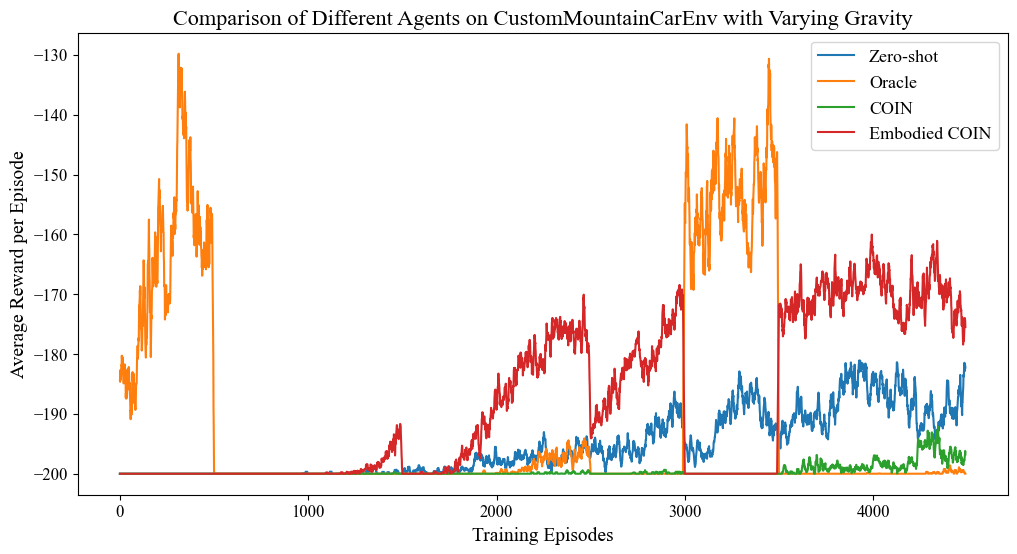

In [24]:
# Plot all means on the same figure
plt.figure(figsize=(12, 6))
plt.plot(np.convolve(rewards_F7_zeroshot[0], np.ones(10)/10, mode='valid'))
plt.plot(np.convolve(rewards_F7_oracle[0], np.ones(10)/10, mode='valid'))
plt.plot(np.convolve(rewards_F7_coin[0], np.ones(10)/10, mode='valid'))
plt.plot(np.convolve(rewards_F7_embodied_coin[0], np.ones(10)/10, mode='valid'))
plt.legend(['Zero-shot', 'Oracle', 'COIN', 'Embodied COIN'])
plt.xlabel('Training Episodes')
plt.ylabel('Average Reward per Episode')
plt.title('Comparison of Different Agents on CustomMountainCarEnv with Varying Gravity')
plt.show()